<a href="https://colab.research.google.com/github/rohilzalke1995/csews-crop-stress-early-warning-system/blob/main/New_Crop_Stress_Early_Warning_System_for_Small_%26_Marginal_Farmers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/New - Crop Stress Early Warning System for Small & Marginal Farmers"

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Fix the widget metadata
if 'widgets' in nb.get('metadata', {}):
    if 'state' not in nb['metadata']['widgets']:
        nb['metadata']['widgets']['state'] = {}

with open(notebook_path, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1)

print("Fixed!")

Fixed!


In [ ]:
!pip install -q timm grad-cam kaggle
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 18.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Done.


# Importing Libraries

In [ ]:
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

#Making Sure to have the same results after every run

In [ ]:
SEED       = 42
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 0.0001
OUTPUT_DIR = './outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


# Settings

In [ ]:
DATA_DIR = './data'
PV_DIR = './data/pv_new/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
PD_DIR = './data/PlantDoc'
OUTPUT_DIR = './outputs'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 0.0001

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('settings are ready')

settings are ready


#Mounting Drive and Setting Up Kaggle

In [ ]:
from google.colab import files, drive

drive.mount('/content/drive')

print('Select your kaggle.json in the file picker...')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')
print('Kaggle ready.')

Mounted at /content/drive
Select your kaggle.json in the file picker...


Saving kaggle.json to kaggle.json
Kaggle ready.


#Downloading PlantVillage Dataset

In [ ]:
if Path(PV_DIR).exists():
  print('PlantVillage Dataset already Downloaded')
else:
  print('Downloading PlantVillage Dataset......(3-5 min)')
  os.makedirs(PV_DIR, exist_ok=True)
  os.system('kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p ./data')
  os.system('unzip -q ./data/new-plant-diseases-dataset.zip -d ./data/pv_new')
  print('Done')

Done


#Downloading PlantDoc Dataset

In [ ]:
if Path(PD_DIR).exists():
  print('PlantDoc Data Already Downloaded')
else:
  print('Downloading PlantDoc Dataset.......(3-5 min)')
  os.system(f'git clone https://github.com/pratikkayal/PlantDoc-Dataset.git {PD_DIR}')
  print('Done')

PD_TEST_DIR = './data/PlantDoc/test'
print(f'PlantDoc test exists: {Path(PD_TEST_DIR).exists()}')

Done
PlantDoc test exists: True


#Finding the correct PlantVillage path

In [ ]:
import os
from pathlib import Path

PV_ROOT = Path('./data/pv_new/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train')

print(f'PV_ROOT exists: {PV_ROOT.exists()}')

class_folders = sorted([
    PV_ROOT / d for d in os.listdir(PV_ROOT)
    if os.path.isdir(PV_ROOT / d)
])

print(f'Class folders found: {len(class_folders)}')
print(f'First 3: {[f.name for f in class_folders[:3]]}')
print(f'Last 3 : {[f.name for f in class_folders[-3:]]}')

PV_ROOT exists: True
Class folders found: 38
First 3: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust']
Last 3 : ['Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


#Counting Images and Creating the Class List

In [ ]:
import os

def count_images(folder_path):
    files = os.listdir(folder_path)
    return sum(1 for f in files
               if f.lower().endswith(('.jpg', '.jpeg', '.png')))

class_counts = {}
for folder in class_folders:
    class_counts[folder.name] = count_images(folder)

total = sum(class_counts.values())
print(f'Total classes : {len(class_counts)}')
print(f'Total images  : {total:,}')
print(f'Avg per class : {total // len(class_counts)}')

CLASS_NAMES  = sorted(class_counts.keys())
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)
print(f'NUM_CLASSES = {NUM_CLASSES}')
print(f'First 3: {CLASS_NAMES[:3]}')

Total classes : 38
Total images  : 70,295
Avg per class : 1849
NUM_CLASSES = 38
First 3: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust']


#Plot Class Distribution

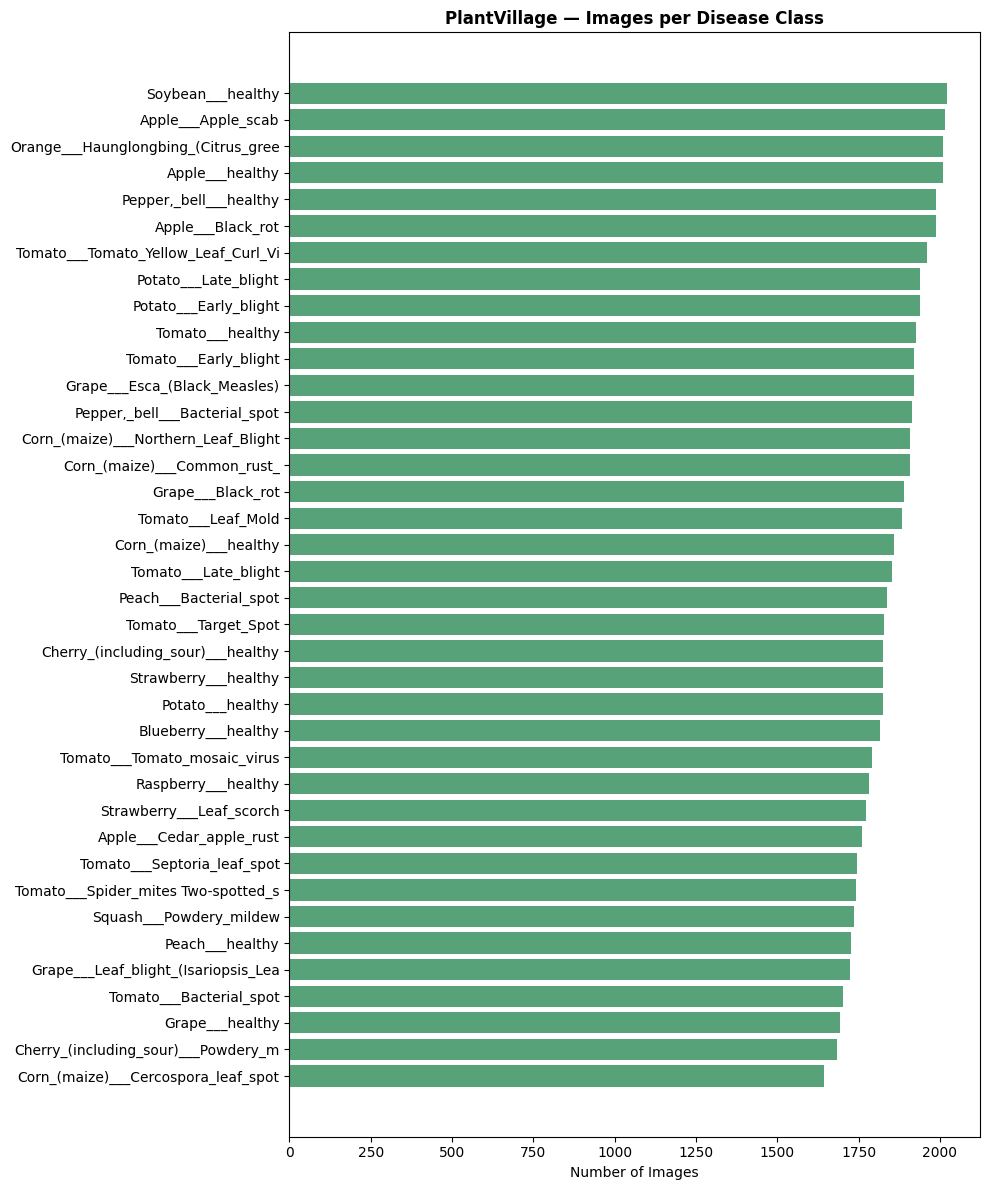

In [ ]:
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1]))
plt.figure(figsize=(10, 12))
plt.barh([k[:35] for k in sorted_counts.keys()],
          sorted_counts.values(), color='#2e8b57', alpha=0.8)
plt.xlabel('Number of Images')
plt.title('PlantVillage — Images per Disease Class', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=120)
plt.show()

#Collecting all image path and labels

In [ ]:
import os

all_paths  = []
all_labels = []

for cls_name in CLASS_NAMES:
    cls_dir = PV_ROOT / cls_name
    if not os.path.exists(cls_dir):
        continue
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files:
        all_paths.append(str(cls_dir / f))
        all_labels.append(CLASS_TO_IDX[cls_name])

print(f'Images: {len(all_paths):,}')
print(f'Labels: {len(all_labels):,}')

Images: 70,295
Labels: 70,295


#Spliting The datset into train/ val/ test

In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(all_paths, all_labels, test_size = 0.2, random_state=SEED, stratify = all_labels)

val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size = 0.5, random_state=SEED, stratify = temp_labels)

print(f'Train: ', len(train_paths))
print(f'Test: ', len(test_paths))
print(f'Val: ', len(val_paths))

Train:  56236
Test:  7030
Val:  7029


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees = 15),
        transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

#Dataset Class

In [ ]:
class LeafDataset:
  def __init__(self, image_paths, labels, transform):
    self.image_paths = image_paths
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    img = Image.open(self.image_paths[idx]).convert('RGB')
    img = self.transform(img)
    labels = self.labels[idx]
    return img, labels

train_dataset = LeafDataset(train_paths, train_labels, train_transform)
val_dataset = LeafDataset(val_paths, val_labels, val_transform)
test_dataset = LeafDataset(test_paths, test_labels, val_transform)

print(f'Train Dataset: {len(train_dataset)} | Validation Dataset: {len(val_dataset)} | Test Dataset: {len(test_dataset)}')

Train Dataset: 56236 | Validation Dataset: 7029 | Test Dataset: 7030


#DataLoaders

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

Train batches: 1758
Val batches  : 220


#Building EfficientNet-B4

In [ ]:
model = timm.create_model('efficientnet_b4', pretrained= True, num_classes = NUM_CLASSES)
model = model.to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'EfficientNet-B4: {total/1_000_000:.1f}M parameters')
print(f'Output classes : {NUM_CLASSES}')

#Quick Test
model.eval()
with torch.no_grad():
  dummy = torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
  out = model(dummy)

print(f'Output Shape: ', {out.shape})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4: 17.6M parameters
Output classes : 38
Output Shape:  {torch.Size([2, 38])}


#Loss, optimiser, scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', patience=3, factor = 0.5)

#Training and Evaluation Function

In [ ]:
def train_one_epoch(model, loader, criterion, optimiser, device):
  model.train()
  Total_loss = 0
  correct = 0
  total = 0
  for images, labels in tqdm(loader, desc='Evaluating', leave=False):
      images, labels = images.to(device), labels.to(device)
      predictions = model(images) #Forward pass — feeds the batch of 32 images through the entire model from input to output. The model returns 32 rows of 38 numbers — one row per image, one number per disease class. The highest number in each row is the model's prediction for that image.
      loss = criterion(predictions, labels) #Calculates how wrong the predictions are. criterion is CrossEntropyLoss. It compares the model's 38 scores for each image against the true label and produces one number — the loss. Higher loss means more wrong. Perfect predictions would give loss of 0.
      optimiser.zero_grad() #Clears all gradients from the previous batch. Gradients are the numbers that tell us which direction to adjust each weight. PyTorch accumulates gradients by default — if we do not clear them, gradients from batch 1 and batch 2 add together and corrupt the update. This line must be called before every backward pass.
      loss.backward() #Backward pass — calculates gradients for every parameter in the model. PyTorch traces back through every calculation that produced the loss and figures out how much each weight contributed to the error. This is called backpropagation. After this line, every parameter in the model has a .grad value attached to it.
      optimiser.step() #Uses the gradients calculated in loss.backward() to update every weight in the model. Adam looks at each weight's gradient and nudges the weight in the direction that reduces the loss. After this line the model is slightly better than it was before this batch.
      Total_loss = Total_loss + loss.item() * images.size(0) #Adds this batch's loss to the running total. .item() converts the loss from a PyTorch tensor to a plain Python number. We multiply by images.size(0) which is the batch size — this gives us the total loss for all 32 images in this batch rather than the average loss per image.
      correct = correct + (predictions.argmax(1) == labels).sum().item() #Counts how many predictions were correct in this batch.
      total = total + images.size(0) #keeping track of how many images we have processed so far this epoch.
      avg_loss = Total_loss / total
      accuracy = correct / total
  return avg_loss, accuracy




def evaluate(model, loader, criterion, device):
  model.eval()
  Total_loss = 0
  correct = 0
  total = 0
  all_preds = []
  all_true = []
  with torch.no_grad():
    for images, labels in tqdm(loader, desc='Evaluating', leave=False):
      images = images.to(device)
      labels = labels.to(device)
      predictions = model(images)
      loss = criterion(predictions, labels)
      Total_loss = Total_loss + loss.item() * images.size(0)
      correct = correct + (predictions.argmax(1) == labels).sum().item()
      total = total + images.size(0)
      all_preds.extend(predictions.argmax(1).cpu().numpy())
      all_true.extend(labels.cpu().numpy())
      avg_loss = Total_loss / total
      accuracy = correct / total

  return avg_loss, accuracy, all_preds, all_true

print("Functions are ready")



Functions are ready


#The Training Loop

In [ ]:
BEST_MODEL_PATH = f'{OUTPUT_DIR}/best_model.pth'
best_val_acc    = 0.0
history         = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f'Training for {EPOCHS} epochs.....')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, DEVICE)

    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'] .append(train_acc)
    history['val_loss']  .append(val_loss)
    history['val_acc']   .append(val_acc)

    note = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        note = '  <- saved'

    print(f'Epoch {epoch:02d}/{EPOCHS} | ' f'Train Loss:{train_loss:.3f} Acc:{train_acc*100:.1f}% | ' f'Val Loss:{val_loss:.3f} Acc:{val_acc*100:.1f}%{note}')

print('=' * 65)
print(f'Best val accuracy: {best_val_acc*100:.2f}%')


Training for 10 epochs.....


Epoch 01/10 | Train Loss:0.459 Acc:87.7% | Val Loss:0.057 Acc:98.3%  <- saved


Epoch 02/10 | Train Loss:0.042 Acc:98.5% | Val Loss:0.026 Acc:99.1%  <- saved


Epoch 03/10 | Train Loss:0.021 Acc:99.3% | Val Loss:0.020 Acc:99.4%  <- saved


Epoch 04/10 | Train Loss:0.014 Acc:99.5% | Val Loss:0.013 Acc:99.6%  <- saved


Epoch 05/10 | Train Loss:0.011 Acc:99.6% | Val Loss:0.013 Acc:99.7%  <- saved


Epoch 06/10 | Train Loss:0.008 Acc:99.7% | Val Loss:0.017 Acc:99.6%


Evaluating:  25%|██▌       | 443/1758 [03:17<09:49,  2.23it/s]

#Ploting the training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='#2e8b57', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#e84343', lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='#2e8b57', lw=2)
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='#e84343', lw=2)
axes[1].axhline(y=92, color='#1e5f8e', linestyle='--', label='Target 92%')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Progress', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=120)
plt.show()

NameError: name 'plt' is not defined

#Testing on PlantVillage Dataset

In [ ]:
model.load_state_dict('BEST_MODEL_PATH', map_location = DEVICE)
_, test_acc, test_pred, test_true = evaluate(model, test_loader, criterion, DEVICE)
test_f1 = f1_score(test_true, test_preds, average = 'macrons', zero_division=0)

print(f'Accuracy: {test_acc*100:.2f} %     (target > 92%)')
print(f'F1 Score: {test_f1:.4f}')

report = classification_report(test_true, test_preds, target_names = CLASS_NAMES, zero_division = 0)
print(report)
with open(f'{OUTPUT_DIR}/test_results.txt','w') as f:
  f.write(f'Accuracy: {test_acc*100:.2f}%\n')
  f.write(f'F1 Score: {test_f1:.4f}\n\n')
  f.write(report)


#Testing on PlantDoc Dataset

In [ ]:
pd_paths = []
pd_labels_list = []

for cls_dir in sorted(Path(PD_TEST_DIR).iterdir()):
    if not cls_dir.is_dir(): continue
    matched = None
    for pv_cls in CLASS_NAMES:
        words = cls_dir.name.lower().replace('_',' ').split()
        if any(w in pv_cls.lower() for w in words if len(w) > 3):
            matched = pv_cls; break
    if not matched: continue
    imgs = []
    for ext in ['*.jpg','*.JPG','*.png','*.PNG']:
        imgs += list(cls_dir.glob(ext))
    for p in imgs:
        pd_paths.append(str(p))
        pd_labels_list.append(CLASS_TO_IDX[matched])

print(f'PlantDoc images matched: {len(pd_paths)}')
if len(pd_paths) > 0:
    pd_ds     = LeafDataset(pd_paths, pd_labels_list, val_transform)
    pd_loader = DataLoader(pd_ds, batch_size=BATCH_SIZE, shuffle=False)
    _, pd_acc, pd_preds, pd_true = evaluate(model, pd_loader, criterion, DEVICE)
    pd_f1 = f1_score(pd_true, pd_preds, average='macro', zero_division=0)
    print(f'PLANTDOC RESULTS (real field photos)')
    print(f'  Accuracy : {pd_acc*100:.2f}%')
    print(f'  Macro F1 : {pd_f1:.4f}  (target >0.78)')
    print(f'  Drop from PlantVillage: {(test_acc-pd_acc)*100:.1f} percentage points')

#Grad-CAM function

In [ ]:
import cv2

def get_gradcam(model, img_tensor, class_idx, device):
    activations = {}
    gradients   = {}

    def save_activation(m, inp, out):
        activations['v'] = out.detach()

    def save_gradient(m, gin, gout):
        gradients['v'] = gout[0].detach()

    last_block = model.blocks[-1]
    h1 = last_block.register_forward_hook(save_activation)
    h2 = last_block.register_full_backward_hook(save_gradient)

    img_tensor = img_tensor.unsqueeze(0).to(device)
    output     = model(img_tensor)
    conf       = F.softmax(output, dim=1)[0, class_idx].item()

    model.zero_grad()
    output[0, class_idx].backward()
    h1.remove(); h2.remove()

    weights = gradients['v'][0].mean(dim=(1, 2))
    acts    = activations['v'][0]
    cam     = torch.zeros(acts.shape[1:], device=device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = F.relu(cam).cpu().numpy()
    if cam.max() > 0: cam = cam / cam.max()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    orig = (img_tensor[0].cpu() * std + mean).clamp(0,1)
    orig = orig.permute(1,2,0).numpy()

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    blended = np.clip(0.55*orig + 0.45*heatmap, 0, 1)
    return blended, orig, conf

print('Grad-CAM ready.')

#Generate Grad-CAM images

In [ ]:
fig, axes = plt.subplots(6, 2, figsize=(10, 24))
fig.suptitle('Grad-CAM: Where did the model look?\n'
             'Left=original  Right=heatmap (red=focused here)',
             fontsize=12, fontweight='bold')

sample_indices = random.sample(range(len(test_dataset)), 6)

for row, idx in enumerate(sample_indices):
    img_tensor, true_label = test_dataset[idx]
    model.eval()
    with torch.no_grad():
        out        = model(img_tensor.unsqueeze(0).to(DEVICE))
        pred_label = out.argmax(1).item()

    cam_img, orig_img, conf = get_gradcam(model, img_tensor, pred_label, DEVICE)
    correct = '✓' if pred_label == true_label else '✗'

    axes[row][0].imshow(orig_img)
    axes[row][0].set_title(f'True: {CLASS_NAMES[true_label][:30]}', fontsize=8)
    axes[row][0].axis('off')

    axes[row][1].imshow(cam_img)
    axes[row][1].set_title(
        f'{correct} Pred: {CLASS_NAMES[pred_label][:25]} ({conf*100:.0f}%)',
        fontsize=8, color='green' if pred_label == true_label else 'red')
    axes[row][1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_results.png', dpi=120)
plt.show()
print('Grad-CAM saved.')

#Save everything

In [ ]:
with open(f'{OUTPUT_DIR}/class_info.json', 'w') as f:
    json.dump({'class_names': CLASS_NAMES, 'class_to_idx': CLASS_TO_IDX}, f, indent=2)

print('Module 1 complete!')
print(f'Files saved in {OUTPUT_DIR}/:')
print(f'  best_model.pth        — trained model weights')
print(f'  class_info.json       — class names for dashboard')
print(f'  training_curves.png   — loss and accuracy graphs')
print(f'  gradcam_results.png   — Grad-CAM visualisations')
print(f'  test_results.txt      — per-class accuracy report')

#Module 2

#Installing packages

In [1]:
# Install the extra libraries needed for Module 2
# These are for satellite data access and processing

!pip install -q pystac-client odc-stac rioxarray requests
# pystac-client — this is the tool that talks to the Element84 Earth Search API and searches for satellite images.
# STAC stands for SpatioTemporal Asset Catalog — it is the standard format for satellite data.
# odc-stac — this stands for Open Data Cube STAC. It takes the satellite images found by pystac-client and loads the actual pixel values into Python as a structured dataset. It handles the Cloud Optimised GeoTIFF format which lets us download only the pixels we need instead of entire giant image files.
# rioxarray — helps us work with the satellite data as a structured grid with coordinates.
# requests — used to call the NASA POWER weather API. This is actually already installed on Colab but we include it to be safe.

print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
All packages installed.


# Imports and Setting

In [2]:
import os
import json
import random
import requests
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd                    # for working with tables of data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pystac_client import Client       # for searching satellite data
import odc.stac                        # for loading satellite pixel values

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'DEVICE: {DEVICE}')

OUTPUT_DIR = './outputs_module2'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# The 4 Vidarbha districts we are studying
# Each entry has: district name, and its GPS bounding box
# Bounding box format: [min_longitude, min_latitude, max_longitude, max_latitude]
DISTRICTS = {
    'Yavatmal' : [77.75, 19.85, 78.25, 20.35],
    'Wardha'   : [78.35, 20.55, 78.85, 21.05],
    'Amravati' : [77.60, 20.80, 78.10, 21.30],
    'Nanded'   : [77.15, 18.95, 77.65, 19.45],
}

# Date range for satellite data
START_DATE = '2020-01-01'
END_DATE   = '2023-03-31'

LOOKBACK = 60

FORECAST = 7

print(f'Output Folder: {OUTPUT_DIR}')
print(f'Districts: {list(DISTRICTS.keys())}')
print(f'Date Range: {START_DATE} to {END_DATE}')
print(f'LSTM Lookback: {LOOKBACK} days')
print(f'Forecast Horizon: {FORECAST} days')
print(f'Settings ready')

DEVICE: cuda
Output Folder: ./outputs_module2
Districts: ['Yavatmal', 'Wardha', 'Amravati', 'Nanded']
Date Range: 2020-01-01 to 2023-03-31
LSTM Lookback: 60 days
Forecast Horizon: 7 days
Settings ready


#Downloading Satellite Dataset

In [3]:
import time
from pystac_client import Client
import odc.stac
import numpy as np
import pandas as pd


def get_ndvi_for_district(district_name, bbox, start_date, end_date):
    """
    Downloads Sentinel-2 satellite data for one district
    and calculates NDVI time series.
    """
    print(f'\nProcessing {district_name}...')

    # Step 1 — Connect to Element84
    catalog = Client.open('https://earth-search.aws.element84.com/v1')
    print(f'  Connected to Element84.')

    # Step 2 — Search for images with less than 20% cloud cover
    search = catalog.search(
        collections = ['sentinel-2-l2a'],
        bbox        = bbox,
        datetime    = f'{start_date}/{end_date}',
        query       = {'eo:cloud_cover': {'lt': 20}}
    )

    items = list(search.items())
    print(f'  Found {len(items)} satellite images.')

    if len(items) == 0:
        print(f'  No images found for {district_name}. Skipping.')
        return None

    # Step 3 — Load pixel values

    print(f'  Loading pixel values (this takes 2-5 minutes)...')

    try:
        ds = odc.stac.load(
            items,
            bands      = ['red', 'nir'],
            bbox       = bbox,
            resolution = 60,
            groupby    = 'solar_day'
        )
    except Exception as e:
        print(f'  Error loading data: {e}')
        return None

    print(f'  Pixel data loaded.')
    print(f'  Total dates in dataset: {len(ds.time.values)}')

    # Step 4 — Calculate NDVI for each date
    records = []

    for date in ds.time.values:
        try:

            red = ds['red'].sel(time=date).values.astype(float)
            nir = ds['nir'].sel(time=date).values.astype(float)

            # Keep only valid pixels
            valid = (red > 0) & (red < 10000) & (nir > 0) & (nir < 10000)

            if valid.sum() < 10:
                continue


            red_valid = red[valid]
            nir_valid = nir[valid]


            ndvi      = (nir_valid - red_valid) / (nir_valid + red_valid + 1e-8)
            mean_ndvi = float(np.mean(ndvi))

            if -0.2 <= mean_ndvi <= 1.0:
                records.append({
                    'date' : pd.Timestamp(date).date(),
                    'ndvi' : round(mean_ndvi, 4)
                })

        except Exception:
            continue

    # Step 5 — Create DataFrame
    df = pd.DataFrame(records)

    if len(df) == 0:
        print(f'  No valid NDVI values for {district_name}.')
        return None

    df = df.sort_values('date').reset_index(drop=True)
    df['district'] = district_name

    print(f'  NDVI calculated for {len(df)} dates.')
    print(f'  Date range : {df["date"].min()} to {df["date"].max()}')
    print(f'  NDVI range : {df["ndvi"].min():.3f} to {df["ndvi"].max():.3f}')

    return df


# ── Run for all 4 districts ───────────────────────────────────────────────────
all_ndvi = []

for district_name, bbox in DISTRICTS.items():
    df = get_ndvi_for_district(district_name, bbox, START_DATE, END_DATE)
    if df is not None:
        all_ndvi.append(df)
        save_path = f'{OUTPUT_DIR}/{district_name}_ndvi.csv'
        df.to_csv(save_path, index=False)
        print(f'  Saved to {save_path}')

# Combine all districts
if len(all_ndvi) > 0:
    master_df = pd.concat(all_ndvi, ignore_index=True)
    master_df.to_csv(f'{OUTPUT_DIR}/all_districts_ndvi.csv', index=False)
    print(f'\nAll districts combined.')
    print(f'Total rows     : {len(master_df):,}')
    print(f'Districts done : {master_df["district"].nunique()}')
    print(f'\nSample data:')
    print(master_df.head(10).to_string(index=False))
else:
    print('No data collected. Check your internet connection.')


Processing Yavatmal...
  Connected to Element84.
  Found 1121 satellite images.
  Loading pixel values (this takes 2-5 minutes)...
  Pixel data loaded.
  Total dates in dataset: 148
  NDVI calculated for 148 dates.
  Date range : 2020-01-12 to 2023-03-27
  NDVI range : 0.096 to 0.703
  Saved to ./outputs_module2/Yavatmal_ndvi.csv

Processing Wardha...
  Connected to Element84.
  Found 1525 satellite images.
  Loading pixel values (this takes 2-5 minutes)...
  Pixel data loaded.
  Total dates in dataset: 287
  NDVI calculated for 287 dates.
  Date range : 2020-01-09 to 2023-03-29
  NDVI range : 0.086 to 0.701
  Saved to ./outputs_module2/Wardha_ndvi.csv

Processing Amravati...
  Connected to Element84.
  Found 385 satellite images.
  Loading pixel values (this takes 2-5 minutes)...
  Pixel data loaded.
  Total dates in dataset: 139
  NDVI calculated for 139 dates.
  Date range : 2020-01-12 to 2023-03-27
  NDVI range : 0.073 to 0.671
  Saved to ./outputs_module2/Amravati_ndvi.csv

Proce

#Fetching weather data from NASA Power

In [4]:
import requests
import pandas as pd
import time


def get_weather_for_district(district_name, bbox, start_date, end_date):
    """
    Fetches daily weather data from NASA POWER API for one district.
    Completely free — no account or API key needed.

    Returns a DataFrame with columns:
    date, temperature_max, temperature_min, rainfall
    """
    print(f'\nFetching weather for {district_name}...')

    # Calculate the centre point of the district bounding box
    # NASA POWER needs one lat/lon point, not a bounding box
    lat = (bbox[1] + bbox[3]) / 2   # average of min and max latitude
    lon = (bbox[0] + bbox[2]) / 2   # average of min and max longitude

    print(f'  Centre point: lat={lat:.3f}, lon={lon:.3f}')

    # Format dates for NASA POWER API — it needs YYYYMMDD format
    start = start_date.replace('-', '')   # '2021-06-01' → '20210601'
    end   = end_date.replace('-', '')     # '2026-03-31' → '20260331'

    # Build the API URL
    # We request three weather variables:
    # T2M_MAX = daily maximum temperature
    # T2M_MIN = daily minimum temperature
    # PRECTOTCORR = daily rainfall
    url = (
        f'https://power.larc.nasa.gov/api/temporal/daily/point'
        f'?parameters=T2M_MAX,T2M_MIN,PRECTOTCORR'
        f'&community=AG'
        f'&longitude={lon}'
        f'&latitude={lat}'
        f'&start={start}'
        f'&end={end}'
        f'&format=JSON'
    )

    # Call the API
    try:
        print(f'  Calling NASA POWER API...')
        response = requests.get(url, timeout=60)

        if response.status_code != 200:
            print(f'  API error: status code {response.status_code}')
            return None

        data = response.json()
        print(f'  Data received successfully.')

    except Exception as e:
        print(f'  Error calling API: {e}')
        return None

    # Extract the weather values from the response
    try:
        properties = data['properties']['parameter']

        temp_max  = properties['T2M_MAX']       # dictionary: date → value
        temp_min  = properties['T2M_MIN']        # dictionary: date → value
        rainfall  = properties['PRECTOTCORR']    # dictionary: date → value

    except KeyError as e:
        print(f'  Error reading response: {e}')
        return None

    # Convert to DataFrame
    records = []

    for date_str in temp_max.keys():
        # date_str is in format '20210601'
        # Convert to proper date format
        try:
            date = pd.to_datetime(date_str, format='%Y%m%d').date()

            t_max = temp_max[date_str]
            t_min = temp_min[date_str]
            rain  = rainfall[date_str]

            # NASA POWER uses -999 for missing values — skip those
            if t_max == -999 or t_min == -999 or rain == -999:
                continue

            records.append({
                'date'            : date,
                'temperature_max' : round(t_max, 2),
                'temperature_min' : round(t_min, 2),
                'rainfall'        : round(rain, 2)
            })

        except Exception:
            continue

    # Create DataFrame
    df = pd.DataFrame(records)

    if len(df) == 0:
        print(f'  No weather data found for {district_name}.')
        return None

    df = df.sort_values('date').reset_index(drop=True)
    df['district'] = district_name

    print(f'  Weather data for {len(df)} days.')
    print(f'  Date range   : {df["date"].min()} to {df["date"].max()}')
    print(f'  Avg max temp : {df["temperature_max"].mean():.1f} C')
    print(f'  Avg rainfall : {df["rainfall"].mean():.1f} mm/day')

    return df


# ── Run for all 4 districts ───────────────────────────────────────────────────
all_weather = []

for district_name, bbox in DISTRICTS.items():
    df = get_weather_for_district(district_name, bbox, START_DATE, END_DATE)
    if df is not None:
        all_weather.append(df)
        save_path = f'{OUTPUT_DIR}/{district_name}_weather.csv'
        df.to_csv(save_path, index=False)
        print(f'  Saved to {save_path}')

    # Small pause between API calls to be polite to the server
    time.sleep(2)

# Combine all districts
if len(all_weather) > 0:
    weather_df = pd.concat(all_weather, ignore_index=True)
    weather_df.to_csv(f'{OUTPUT_DIR}/all_districts_weather.csv', index=False)
    print(f'\nAll weather data combined.')
    print(f'Total rows     : {len(weather_df):,}')
    print(f'Districts done : {weather_df["district"].nunique()}')
    print(f'\nSample data:')
    print(weather_df.head(8).to_string(index=False))
else:
    print('No weather data collected. Check your internet connection.')


Fetching weather for Yavatmal...
  Centre point: lat=20.100, lon=78.000
  Calling NASA POWER API...
  Data received successfully.
  Weather data for 1186 days.
  Date range   : 2020-01-01 to 2023-03-31
  Avg max temp : 32.8 C
  Avg rainfall : 3.0 mm/day
  Saved to ./outputs_module2/Yavatmal_weather.csv

Fetching weather for Wardha...
  Centre point: lat=20.800, lon=78.600
  Calling NASA POWER API...
  Data received successfully.
  Weather data for 1186 days.
  Date range   : 2020-01-01 to 2023-03-31
  Avg max temp : 32.2 C
  Avg rainfall : 3.3 mm/day
  Saved to ./outputs_module2/Wardha_weather.csv

Fetching weather for Amravati...
  Centre point: lat=21.050, lon=77.850
  Calling NASA POWER API...
  Data received successfully.
  Weather data for 1186 days.
  Date range   : 2020-01-01 to 2023-03-31
  Avg max temp : 32.5 C
  Avg rainfall : 3.1 mm/day
  Saved to ./outputs_module2/Amravati_weather.csv

Fetching weather for Nanded...
  Centre point: lat=19.200, lon=77.400
  Calling NASA POW

#Merging NDVI and Weather Data

Loading saved data files...
NDVI data    : 709 rows
Weather data : 4,744 rows

Merging NDVI and weather data...
Combined rows: 709

Missing values after merge:
date               0
ndvi               0
district           0
temperature_max    0
temperature_min    0
rainfall           0
dtype: int64

Final combined dataset: 709 rows
Districts             : 4
Date range            : 2020-01-09 to 2023-03-29

Rows per district:
district
Amravati    139
Nanded      135
Wardha      287
Yavatmal    148

Sample data (first 8 rows):
      date   ndvi district  temperature_max  temperature_min  rainfall
2020-01-12 0.4789 Amravati            24.74             7.19      0.00
2020-01-22 0.3281 Amravati            28.83            14.06      0.00
2020-01-27 0.4309 Amravati            30.12            11.72      0.01
2020-02-06 0.3256 Amravati            27.81            14.37      1.11
2020-02-11 0.3728 Amravati            28.50            13.24      0.00
2020-02-16 0.3878 Amravati            32.36 

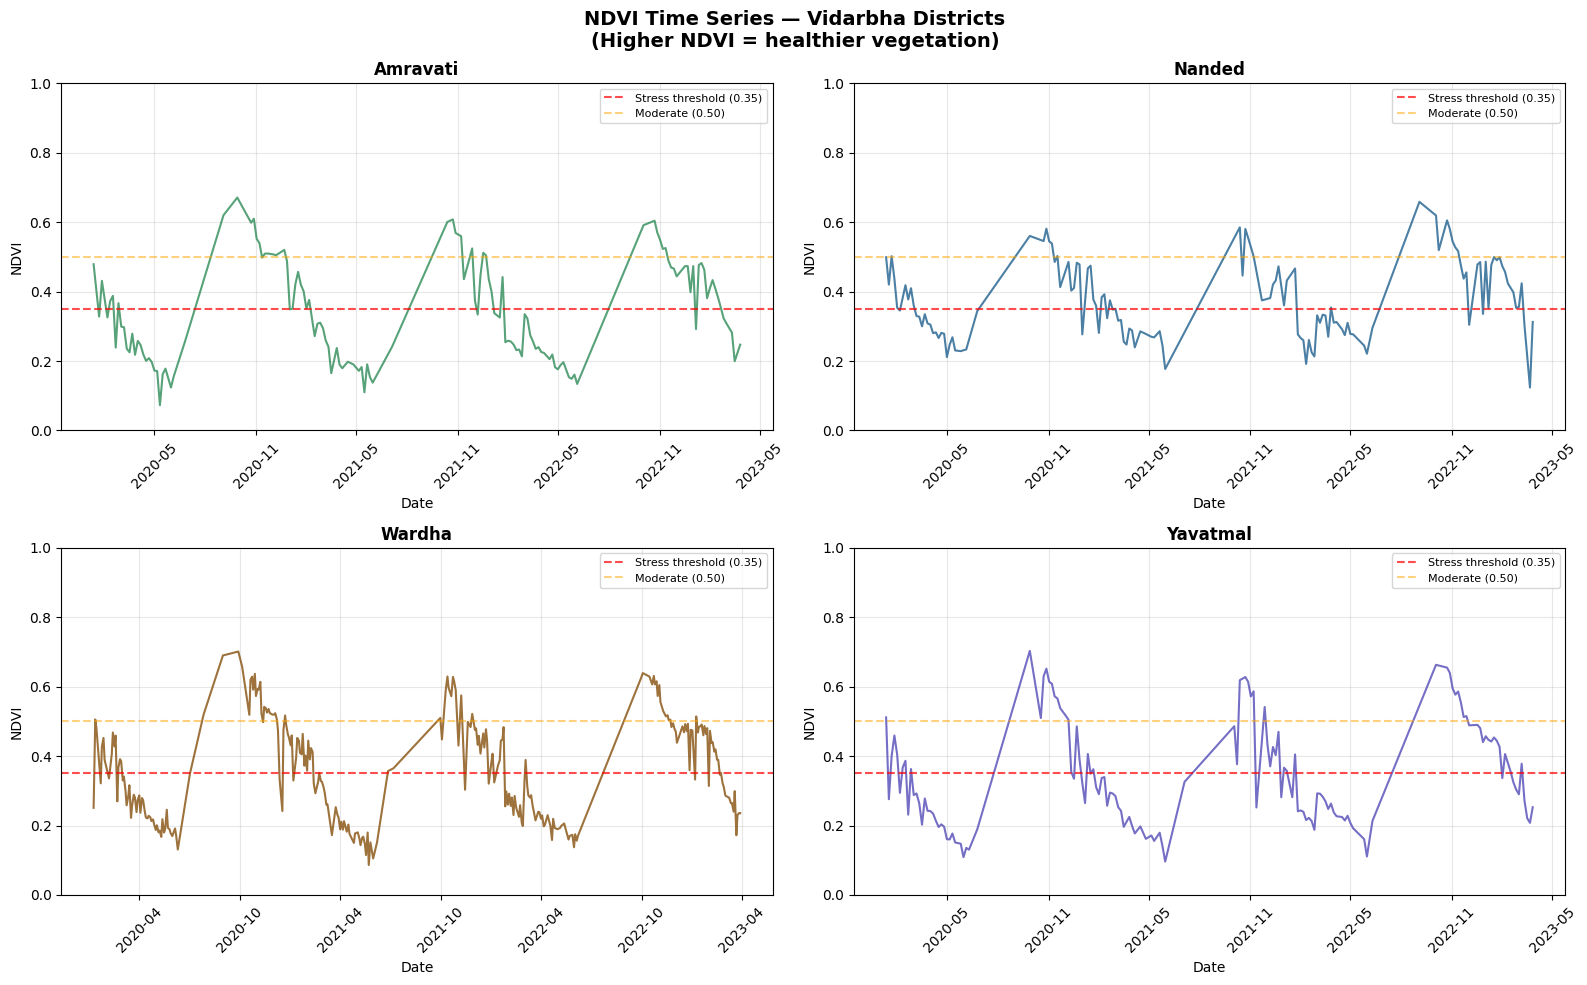

NDVI time series plot saved.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ── Load the saved CSV files ──────────────────────────────────────────────────
print('Loading saved data files...')

# Load NDVI data
ndvi_df = pd.read_csv(f'{OUTPUT_DIR}/all_districts_ndvi.csv')
ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
print(f'NDVI data    : {len(ndvi_df):,} rows')

# Load weather data
weather_df = pd.read_csv(f'{OUTPUT_DIR}/all_districts_weather.csv')
weather_df['date'] = pd.to_datetime(weather_df['date'])
print(f'Weather data : {len(weather_df):,} rows')

# ── Merge NDVI and weather on date and district ───────────────────────────────
# We use a left join — keep all NDVI rows, match weather where available
print('\nMerging NDVI and weather data...')

combined_df = pd.merge(
    ndvi_df,        # left table — NDVI (satellite dates)
    weather_df,     # right table — weather (daily)
    on        = ['date', 'district'],   # match on both date AND district
    how       = 'left'                  # keep all NDVI rows
)

print(f'Combined rows: {len(combined_df):,}')

# ── Check for missing values after merge ──────────────────────────────────────
print('\nMissing values after merge:')
print(combined_df.isnull().sum())

# Fill any small gaps in weather data using forward fill
# Forward fill = use the previous day value if today is missing
combined_df['temperature_max'] = combined_df['temperature_max'].fillna(method='ffill')
combined_df['temperature_min'] = combined_df['temperature_min'].fillna(method='ffill')
combined_df['rainfall']        = combined_df['rainfall'].fillna(0)

# Drop any remaining rows with missing NDVI
combined_df = combined_df.dropna(subset=['ndvi'])
combined_df = combined_df.sort_values(['district', 'date']).reset_index(drop=True)

print(f'\nFinal combined dataset: {len(combined_df):,} rows')
print(f'Districts             : {combined_df["district"].nunique()}')
print(f'Date range            : {combined_df["date"].min().date()} to {combined_df["date"].max().date()}')

# ── Show summary per district ─────────────────────────────────────────────────
print('\nRows per district:')
print(combined_df.groupby('district').size().to_string())

# ── Show sample data ──────────────────────────────────────────────────────────
print('\nSample data (first 8 rows):')
print(combined_df.head(8).to_string(index=False))

# ── Save combined dataset ─────────────────────────────────────────────────────
combined_df.to_csv(f'{OUTPUT_DIR}/combined_dataset.csv', index=False)
print(f'\nCombined dataset saved to {OUTPUT_DIR}/combined_dataset.csv')

# ── Plot NDVI time series for all districts ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NDVI Time Series — Vidarbha Districts\n'
             '(Higher NDVI = healthier vegetation)',
             fontsize=14, fontweight='bold')

colors = ['#2e8b57', '#1e5f8e', '#854F0B', '#534AB7']
districts = combined_df['district'].unique()

for ax, district, color in zip(axes.flat, districts, colors):
    district_data = combined_df[combined_df['district'] == district].copy()

    ax.plot(district_data['date'], district_data['ndvi'],
            color=color, linewidth=1.5, alpha=0.8)

    # Add horizontal lines to show stress thresholds
    ax.axhline(y=0.35, color='red',    linestyle='--',
               alpha=0.7, label='Stress threshold (0.35)')
    ax.axhline(y=0.50, color='orange', linestyle='--',
               alpha=0.5, label='Moderate (0.50)')

    ax.set_title(district, fontweight='bold', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('NDVI')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Format x axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ndvi_time_series.png', dpi=120, bbox_inches='tight')
plt.show()
print('NDVI time series plot saved.')

#Creating Stress Labels

Loading combined dataset...
Rows loaded: 709

Creating stress labels...
Stress threshold : NDVI drop > 0.15
Forecast horizon : 7 days ahead

  Processing Amravati...
  Rows: 139
  Stress events    : 14 (10.6%)
  No stress events : 118 (89.4%)

  Processing Nanded...
  Rows: 135
  Stress events    : 14 (10.9%)
  No stress events : 114 (89.1%)

  Processing Wardha...
  Rows: 287
  Stress events    : 14 (5.0%)
  No stress events : 266 (95.0%)

  Processing Yavatmal...
  Rows: 148
  Stress events    : 21 (14.9%)
  No stress events : 120 (85.1%)

Final labelled dataset:
  Total rows   : 681
  Stress = 1   : 63 (9.3%)
  No stress = 0: 618 (90.7%)

Sample data with labels:
      date district   ndvi  temperature_max  rainfall  stress_label
2020-01-12 Amravati 0.4789            24.74      0.00             0
2020-01-22 Amravati 0.3281            28.83      0.00             0
2020-01-27 Amravati 0.4309            30.12      0.01             0
2020-02-06 Amravati 0.3256            27.81      1.11

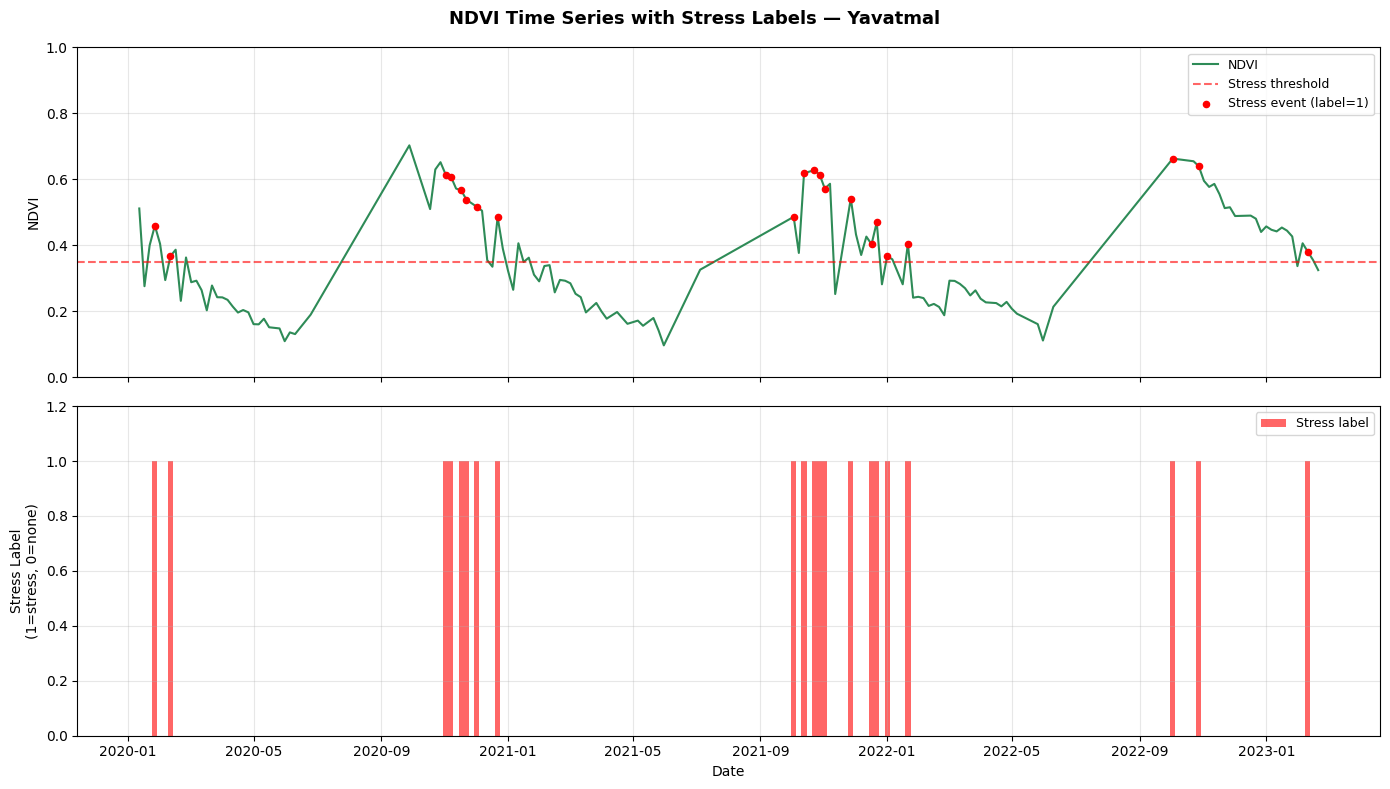

Stress labels plot saved.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ── Load combined dataset ─────────────────────────────────────────────────────
print('Loading combined dataset...')
combined_df = pd.read_csv(f'{OUTPUT_DIR}/combined_dataset.csv')
combined_df['date'] = pd.to_datetime(combined_df['date'])
print(f'Rows loaded: {len(combined_df):,}')

# ── Create stress label for each district separately ──────────────────────────
# We must do this per district — we do not want to compare Yavatmal
# NDVI values with Wardha NDVI values

STRESS_THRESHOLD = 0.15   # NDVI drop of more than this = stress
FORECAST_DAYS    = 7      # how many days ahead we look

print(f'\nCreating stress labels...')
print(f'Stress threshold : NDVI drop > {STRESS_THRESHOLD}')
print(f'Forecast horizon : {FORECAST_DAYS} days ahead')

all_labelled = []

for district in combined_df['district'].unique():

    # Get data for this district only
    district_data = combined_df[combined_df['district'] == district].copy()
    district_data = district_data.sort_values('date').reset_index(drop=True)

    print(f'\n  Processing {district}...')
    print(f'  Rows: {len(district_data)}')

    # For each row, look FORECAST_DAYS rows ahead and check NDVI
    # Note: we look ahead by rows not calendar days
    # because satellite data has gaps (not every day)
    labels = []

    for i in range(len(district_data)):

        # Check if there is a row FORECAST_DAYS positions ahead
        future_idx = i + FORECAST_DAYS

        if future_idx >= len(district_data):
            # No future data available — cannot create label
            labels.append(np.nan)
            continue

        current_ndvi = district_data.loc[i, 'ndvi']
        future_ndvi  = district_data.loc[future_idx, 'ndvi']

        # How much did NDVI drop?
        ndvi_drop = current_ndvi - future_ndvi

        # If drop is greater than threshold — stress is coming
        if ndvi_drop > STRESS_THRESHOLD:
            labels.append(1)   # stress
        else:
            labels.append(0)   # no stress

    # Add labels to district data
    district_data['stress_label'] = labels

    # Remove rows where we could not create a label
    district_data = district_data.dropna(subset=['stress_label'])
    district_data['stress_label'] = district_data['stress_label'].astype(int)

    # Count stress vs no stress
    stress_count    = district_data['stress_label'].sum()
    no_stress_count = len(district_data) - stress_count
    stress_pct      = stress_count / len(district_data) * 100

    print(f'  Stress events    : {stress_count} ({stress_pct:.1f}%)')
    print(f'  No stress events : {no_stress_count} ({100-stress_pct:.1f}%)')

    all_labelled.append(district_data)

# ── Combine all districts ─────────────────────────────────────────────────────
labelled_df = pd.concat(all_labelled, ignore_index=True)
labelled_df = labelled_df.sort_values(['district', 'date']).reset_index(drop=True)

print(f'\nFinal labelled dataset:')
print(f'  Total rows   : {len(labelled_df):,}')
print(f'  Stress = 1   : {labelled_df["stress_label"].sum():,} ({labelled_df["stress_label"].mean()*100:.1f}%)')
print(f'  No stress = 0: {(labelled_df["stress_label"]==0).sum():,} ({(1-labelled_df["stress_label"].mean())*100:.1f}%)')

# ── Show sample ───────────────────────────────────────────────────────────────
print(f'\nSample data with labels:')
print(labelled_df[['date','district','ndvi','temperature_max',
                    'rainfall','stress_label']].head(10).to_string(index=False))

# ── Save labelled dataset ─────────────────────────────────────────────────────
labelled_df.to_csv(f'{OUTPUT_DIR}/labelled_dataset.csv', index=False)
print(f'\nLabelled dataset saved.')

# ── Plot NDVI with stress labels for one district ─────────────────────────────
# This shows visually where stress events occur on the NDVI timeline

sample_district = 'Yavatmal'
plot_data = labelled_df[labelled_df['district'] == sample_district].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'NDVI Time Series with Stress Labels — {sample_district}',
             fontsize=13, fontweight='bold')

# Top plot — NDVI line
axes[0].plot(plot_data['date'], plot_data['ndvi'],
             color='#2e8b57', linewidth=1.5, label='NDVI')
axes[0].axhline(y=0.35, color='red', linestyle='--',
                alpha=0.6, label='Stress threshold')

# Highlight stress periods in red
stress_dates = plot_data[plot_data['stress_label'] == 1]
axes[0].scatter(stress_dates['date'], stress_dates['ndvi'],
                color='red', s=20, zorder=5, label='Stress event (label=1)')

axes[0].set_ylabel('NDVI')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom plot — stress label as bar chart
axes[1].bar(plot_data['date'], plot_data['stress_label'],
            color='red', alpha=0.6, width=5, label='Stress label')
axes[1].set_ylabel('Stress Label\n(1=stress, 0=none)')
axes[1].set_xlabel('Date')
axes[1].set_ylim(0, 1.2)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/stress_labels.png', dpi=120, bbox_inches='tight')
plt.show()
print('Stress labels plot saved.')

#Creating Sliding Window Sequences

In [7]:
#Row 1:  2021-06-03  NDVI=0.41  Temp=38.2  Rain=0.0  Label=0
#Row 2:  2021-06-08  NDVI=0.39  Temp=39.1  Rain=2.4  Label=1
#Row 3:  2021-06-13  NDVI=0.44  Temp=35.6  Rain=12.1 Label=0
#...

#The LSTM model does not look at one date at a time. It looks at 60 consecutive days of history and predicts whether stress will occur in the next 7 days.

#The LSTM needs sequences — groups of 60 consecutive rows bundled together as one input:
#Sequence 1:  Rows 1 to 60   → Label from Row 60
#Sequence 2:  Rows 2 to 61   → Label from Row 61
#Sequence 3:  Rows 3 to 62   → Label from Row 62
#...

#This is called a sliding window — we slide a window of 60 rows across the dataset one step at a time. Each position of the window creates one training example.

#Visual explanation of sliding window
#Data:  [D1, D2, D3, D4, D5, D6, D7 ... D300]

#Window size = 4 (we use 60 but 4 is easier to draw)

#Sequence 1:  [D1, D2, D3, D4]  → predict label at D4
#Sequence 2:  [D2, D3, D4, D5]  → predict label at D5
#Sequence 3:  [D3, D4, D5, D6]  → predict label at D6
#Sequence 4:  [D4, D5, D6, D7]  → predict label at D7

In [ ]:
this is my code:

print(f'Loading the labelled dataset')
labelled_df = pd.read_csv(f'{OUTPUT_DIR}/labelled_dataset.csv')
labelled_df['date'] = pd.to_datetime(labelled_df['date'])
print(f'Rows Loaded: {len(labelled_df)}')


FEATURE_COLS = ['ndvi', 'temperature_max', 'temperature_min', 'rainfall']
LABEL_COLS = ['stress_label']
LOOKBACK = 60

print(f'Features Used: {FEATURE_COLS}')
print(f'Lokback WIndow: {LOOKBACK} time steps')

all_X = []
all_y = []

for district in labelled_df['district'].unique():
  print(f'Creating sequences for {district}')
  district_data = labelled_df[labelled_df['district']==district].sort_values('date').reset_index(drop=True)

  features = district_data[FEATURE_COLS].values
  lalebs = district_data[LABEL_COLS].values

  scaler = StandardScaler()
  features = scaler.fit_transform(features)

  district_X = []
  district_y = []

  for i in range(LOOKBACK, len(features)):
    sequence = features[i - LOOKBACK: i]
    label = labels[i]
    district_X = district_X.append(sequence)
    district_y = district_y.append(label)

  district_X = np.array(district_X)
  district_y = np.array(district_y)

  print(f'  Sequences created : {len(district_X)}')
  print(f'  Sequence shape    : {district_X[0].shape}')
  print(f'  Stress sequences  : {district_y.sum()} ({district_y.mean()*100:.1f}%)')

  all_X = all_X.append(district_X)
  all_y = all_y.append(district_y)

#Combining all district
X = np.concatenate(all_X, axis = 0)
y = np.concatenate(all_y, axis = 0)

print(f'Final dataset....')
print(f'X Shape: {X.shape}')
print(f'y Shape: {y.shape}')
print(f'Meaning of X Shape: {X.shape[0]} sequences, {X.shape[1]} time steps, {X.shape[2]} features')
print(f'  Stress = 1 : {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'  No stress  : {(y==0).sum():,} ({(1-y.mean())*100:.1f}%)')

# ── Showing one example sequence ─────────────────────────────────────────────────
print(f'\nExample — first sequence:')
print(f'  Shape      : {X[0].shape}  (60 time steps, 4 features)')
print(f'  Label      : {y[0]}  (0=no stress, 1=stress)')
print(f'  First 3 time steps:')
print(f'  {"Step":>5}  {"NDVI":>8}  {"TempMax":>8}  {"TempMin":>8}  {"Rain":>8}')
for i in range(3):
  print(f'  {i+1:>5}  {X[0][i][0]:>8.3f}  {X[0][i][1]:>8.3f}  {X[0][i][2]:>8.3f}  {X[0][i][3]:>8.3f}')

# ── Save sequences ────────────────────────────────────────────────────────────
np.save(f'{OUTPUT_DIR}/X_sequences.npy', X)
np.save(f'{OUTPUT_DIR}/y_labels.npy',    y)
print(f'\nSequences saved.')
print(f'  X_sequences.npy : {X.shape}')
print(f'  y_labels.npy    : {y.shape}')

Loading labelled dataset...
Rows loaded: 681

Features used  : ['ndvi', 'temperature_max', 'temperature_min', 'rainfall']
Lookback window: 60 time steps

Creating sequences for Amravati...
  Sequences created : 72
  Sequence shape    : (60, 4)
  Stress sequences  : 10 (13.9%)

Creating sequences for Nanded...
  Sequences created : 68
  Sequence shape    : (60, 4)
  Stress sequences  : 11 (16.2%)

Creating sequences for Wardha...
  Sequences created : 220
  Sequence shape    : (60, 4)
  Stress sequences  : 11 (5.0%)

Creating sequences for Yavatmal...
  Sequences created : 81
  Sequence shape    : (60, 4)
  Stress sequences  : 13 (16.0%)

Final dataset:
  X shape : (441, 60, 4)
  y shape : (441,)
  Meaning of X shape: (441 sequences, 60 time steps, 4 features)
  Stress = 1 : 45 (10.2%)
  No stress  : 396 (89.8%)

Example — first sequence:
  Shape      : (60, 4)  (60 time steps, 4 features)
  Label      : 0  (0=no stress, 1=stress)
  First 3 time steps:
   Step      NDVI   TempMax   Temp

In [8]:
#Code generated by Claude:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


# ── Load labelled dataset ─────────────────────────────────────────────────────
print('Loading labelled dataset...')
labelled_df = pd.read_csv(f'{OUTPUT_DIR}/labelled_dataset.csv')
labelled_df['date'] = pd.to_datetime(labelled_df['date'])
print(f'Rows loaded: {len(labelled_df):,}')

# ── Define which columns are features ────────────────────────────────────────
# These are the 4 values the LSTM sees at each time step
FEATURE_COLS = ['ndvi', 'temperature_max', 'temperature_min', 'rainfall']
LABEL_COL    = 'stress_label'
LOOKBACK     = 60   # how many time steps the LSTM looks back

print(f'\nFeatures used  : {FEATURE_COLS}')
print(f'Lookback window: {LOOKBACK} time steps')

# ── Create sequences for each district separately ─────────────────────────────
# Important — we must not mix sequences across districts
# A sequence must come from one district only

all_X = []   # will hold all input sequences
all_y = []   # will hold all labels

for district in labelled_df['district'].unique():

    print(f'\nCreating sequences for {district}...')

    # Get data for this district only — sorted by date
    district_data = labelled_df[
        labelled_df['district'] == district
    ].sort_values('date').reset_index(drop=True)

    # Extract feature values as a numpy array
    # Shape: (num_rows, num_features) e.g. (580, 4)
    features = district_data[FEATURE_COLS].values
    labels   = district_data[LABEL_COL].values

    # Normalise features using StandardScaler
    # This scales each feature to have mean=0 and std=1
    # Important for LSTM — large differences in scale between
    # features (e.g. NDVI is 0-1, temperature is 20-45)
    # can confuse the model
    scaler   = StandardScaler()
    features = scaler.fit_transform(features)

    # Create sliding window sequences
    district_X = []
    district_y = []

    for i in range(LOOKBACK, len(features)):
        # Take LOOKBACK rows ending at position i
        # as one input sequence
        sequence = features[i - LOOKBACK : i]   # shape: (60, 4)
        label    = labels[i]                      # single number: 0 or 1

        district_X.append(sequence)
        district_y.append(label)

    district_X = np.array(district_X)   # shape: (num_sequences, 60, 4)
    district_y = np.array(district_y)   # shape: (num_sequences,)

    print(f'  Sequences created : {len(district_X)}')
    print(f'  Sequence shape    : {district_X[0].shape}')
    print(f'  Stress sequences  : {district_y.sum()} ({district_y.mean()*100:.1f}%)')

    all_X.append(district_X)
    all_y.append(district_y)

# ── Combine all districts ─────────────────────────────────────────────────────
X = np.concatenate(all_X, axis=0)   # shape: (total_sequences, 60, 4)
y = np.concatenate(all_y, axis=0)   # shape: (total_sequences,)

print(f'\nFinal dataset:')
print(f'  X shape : {X.shape}')
print(f'  y shape : {y.shape}')
print(f'  Meaning of X shape: ({X.shape[0]} sequences, {X.shape[1]} time steps, {X.shape[2]} features)')
print(f'  Stress = 1 : {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'  No stress  : {(y==0).sum():,} ({(1-y.mean())*100:.1f}%)')

# ── Show one example sequence ─────────────────────────────────────────────────
print(f'\nExample — first sequence:')
print(f'  Shape      : {X[0].shape}  (60 time steps, 4 features)')
print(f'  Label      : {y[0]}  (0=no stress, 1=stress)')
print(f'  First 3 time steps:')
print(f'  {"Step":>5}  {"NDVI":>8}  {"TempMax":>8}  {"TempMin":>8}  {"Rain":>8}')
for i in range(3):
    print(f'  {i+1:>5}  {X[0][i][0]:>8.3f}  {X[0][i][1]:>8.3f}  {X[0][i][2]:>8.3f}  {X[0][i][3]:>8.3f}')

# ── Save sequences ────────────────────────────────────────────────────────────
np.save(f'{OUTPUT_DIR}/X_sequences.npy', X)
np.save(f'{OUTPUT_DIR}/y_labels.npy',    y)
print(f'\nSequences saved.')
print(f'  X_sequences.npy : {X.shape}')
print(f'  y_labels.npy    : {y.shape}')

Loading labelled dataset...
Rows loaded: 681

Features used  : ['ndvi', 'temperature_max', 'temperature_min', 'rainfall']
Lookback window: 60 time steps

Creating sequences for Amravati...
  Sequences created : 72
  Sequence shape    : (60, 4)
  Stress sequences  : 10 (13.9%)

Creating sequences for Nanded...
  Sequences created : 68
  Sequence shape    : (60, 4)
  Stress sequences  : 11 (16.2%)

Creating sequences for Wardha...
  Sequences created : 220
  Sequence shape    : (60, 4)
  Stress sequences  : 11 (5.0%)

Creating sequences for Yavatmal...
  Sequences created : 81
  Sequence shape    : (60, 4)
  Stress sequences  : 13 (16.0%)

Final dataset:
  X shape : (441, 60, 4)
  y shape : (441,)
  Meaning of X shape: (441 sequences, 60 time steps, 4 features)
  Stress = 1 : 45 (10.2%)
  No stress  : 396 (89.8%)

Example — first sequence:
  Shape      : (60, 4)  (60 time steps, 4 features)
  Label      : 0  (0=no stress, 1=stress)
  First 3 time steps:
   Step      NDVI   TempMax   Temp

In [ ]:
#The feature values are normalised — they are no longer in their original scale. NDVI was 0 to 1, temperature was 20 to 45, rainfall was 0 to 50. After StandardScaler all values are centred around 0 with similar spread. This helps the LSTM learn equally from all features.
#X shape is (2132, 60, 4) — this means 2132 training sequences, each with 60 time steps, each time step having 4 features. This 3D shape is exactly what the LSTM expects as input.

#Spliting dataset into Train and Test set

In [9]:
print(f'Loading sequences.....')
X = np.load(f'{OUTPUT_DIR}/X_sequences.npy')
y = np.load(f'{OUTPUT_DIR}/y_labels.npy')

print(f'X Shape: {X.shape}')
print(f'y Shape: {y.shape}')

total = len(X)
train_size = int(total * 0.80)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print(f'Split Sequence......')
print(f'Total Sequence: {total:,}')
print(f'Train Sequence: {len(X_train):,} (80%)')
print(f'Test Sequences: {len(X_test):,} (20%)')
print(f'\n  Train — Stress: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'  Test  — Stress: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')

class StressDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype = torch.float32)
    self.y = torch.tensor(y, dtype = torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

train_dataset = StressDataset(X_train, y_train)
test_dataset = StressDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

print(f'Dataloaders are ready: ')
print(f'Train batches: {len(train_dataset)}')
print(f'Test Batches: {len(test_loader)}')

# ── Quick test ────────────────────────────────────────────────────────────────
sample_X, sample_y = next(iter(train_loader))
print(f'\nOne batch shape:')
print(f'  X batch : {sample_X.shape}')
print(f'  y batch : {sample_y.shape}')
print(f'  Meaning : ({sample_X.shape[0]} sequences, {sample_X.shape[1]} time steps, {sample_X.shape[2]} features)')



Loading sequences.....
X Shape: (441, 60, 4)
y Shape: (441,)
Split Sequence......
Total Sequence: 441
Train Sequence: 352 (80%)
Test Sequences: 89 (20%)

  Train — Stress: 32 (9.1%)
  Test  — Stress: 13  (14.6%)
Dataloaders are ready: 
Train batches: 352
Test Batches: 3

One batch shape:
  X batch : torch.Size([32, 60, 4])
  y batch : torch.Size([32])
  Meaning : (32 sequences, 60 time steps, 4 features)


#Building LSTM Model

In [11]:
import torch
import torch.nn as nn


class CropStressLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, dropout):
        """
        input_size  : number of features at each time step (4)
        hidden_size : how many memory units the LSTM has (64)
        num_layers  : how many LSTM layers stacked together (2)
        dropout     : fraction of neurons to randomly switch off (0.3)
        """
        super(CropStressLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )

        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        lstm_out, _  = self.lstm(x)
        last_output  = lstm_out[:, -1, :]
        out          = self.dropout(last_output)
        out          = self.fc(out)
        out          = self.sigmoid(out)
        out          = out.squeeze(1)
        return out


# ── Create model ──────────────────────────────────────────────────────────────
INPUT_SIZE  = 4
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.3

model = CropStressLSTM(
    input_size  = INPUT_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model          : CropStressLSTM')
print(f'Input size     : {INPUT_SIZE} features per time step')
print(f'Hidden size    : {HIDDEN_SIZE} memory units')
print(f'Num layers     : {NUM_LAYERS} LSTM layers')
print(f'Dropout        : {DROPOUT}')
print(f'Total params   : {total_params:,}')

# ── Quick test ────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    sample_X, _ = next(iter(train_loader))
    sample_X    = sample_X.to(DEVICE)
    output      = model(sample_X)

print(f'\nTest forward pass:')
print(f'  Input shape  : {sample_X.shape}')
print(f'  Output shape : {output.shape}')
print(f'  Sample outputs (first 5): {output[:5].cpu().numpy().round(3)}')
print(f'  All values between 0 and 1: {((output >= 0) & (output <= 1)).all().item()}')
print(f'\nModel ready for training.')

Model          : CropStressLSTM
Input size     : 4 features per time step
Hidden size    : 64 memory units
Num layers     : 2 LSTM layers
Dropout        : 0.3
Total params   : 51,265

Test forward pass:
  Input shape  : torch.Size([32, 60, 4])
  Output shape : torch.Size([32])
  Sample outputs (first 5): [0.473 0.467 0.473 0.471 0.473]
  All values between 0 and 1: True

Model ready for training.


#Training Loop

In [ ]:
#1. call Binary Cross Entropy Loss
#2. Call model optimizer using torch.optim
#3. Call Scheduler — reduce learning rate if no improvement
#4. Print -> Loss function, Optimizer & Scheduler
#5. set epoch to 20, best model path to f'{OUTPUT_DIR}/best_lstm_model.pth' & est_auroc to 00


In [14]:
#Binary Cross Entropy Loss
criterion = nn.BCELoss()

#Adam optimiser
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

#Scheduler — reduce learning rate if no improvement
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'max', patience = 3, factor = 0.5)

print(f'Loss Function: Binary Cross Entropy Loss')
print(f'Optimizer: Adam')
print(f'Scheduler: ReduceLROnPlateau(patience = 3)')

EPOCHS = 20
BEST_MODEL_PATH = f'{OUTPUT_DIR}/best_lstm_model.pth'
best_auroc = 0

history  = {
    'train_loss': [],
    'test_loss' : [],
    'test_auroc' : []

}
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0
  total = 0
  for sequences, labels in loader:
    sequences = sequences.to(device)
    labels = labels.to(device)
    predictions = model(sequences) #Forward pass
    loss = criterion(predictions, labels) #Calculates how wrong the predictions are. criterion is CrossEntropyLoss. It compares the model's 38 scores for each image against the true label and produces one number — the loss. Higher loss means more wrong. Perfect predictions would give loss of 0.
    optimizer.zero_grad() #Clears all gradients from the previous batch. Gradients are the numbers that tell us which direction to adjust each weight. PyTorch accumulates gradients by default — if we do not clear them, gradients from batch 1 and batch 2 add together and corrupt the update. This line must be called before every backward pass.
    loss.backward() #Backward pass — calculates gradients for every parameter in the model. PyTorch traces back through every calculation that produced the loss and figures out how much each weight contributed to the error. This is called backpropagation. After this line, every parameter in the model has a .grad value attached to it.
    optimizer.step() #Uses the gradients calculated in loss.backward() to update every weight in the model. Adam looks at each weight's gradient and nudges the weight in the direction that reduces the loss. After this line the model is slightly better than it was before this batch.
    running_loss= running_loss + loss.item() * sequences.size(0)
    total = total + sequences.size(0)
  return running_loss/ total

def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss = 0
  total = 0
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for sequences, labels in loader:
      sequences = sequences.to(device)
      labels = labels.to(device)
      predictions = model(sequences)
      loss = criterion(predictions, labels)
      running_loss = running_loss + loss.item() * sequences.size(0)
      total = total + sequences.size(0)
      all_preds.extend(predictions.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())
  avg_loss = running_loss / total

  try:
    auroc = roc_auc_score(all_labels, all_preds)
  except Exception:
    auroc = 0.5

  return avg_loss, auroc, all_preds, all_labels


print(f'\nStarting training for {EPOCHS} epochs')
print('='*65)

for epoch in range(1, EPOCHS + 1):
  train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

  test_loss, test_auroc, _, _ = evaluate(model, test_loader, criterion, DEVICE)

  scheduler.step(test_auroc)

  history['train_loss'].append(train_loss)
  history['test_loss'].append(test_loss)
  history['test_auroc'].append(test_auroc)

  note = ''
  if test_auroc > best_auroc:
    best_auroc = test_auroc
    torch.save(model.state_dict(), BEST_MODEL_PATH)
    note = '  <- saved'

  print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss:{train_loss:.4f} | '
          f'Test Loss:{test_loss:.4f} | '
          f'AUROC:{test_auroc:.4f}{note}')

print('=' * 65)
print(f'Best AUROC: {best_auroc:.4f}')

if best_auroc >= 0.80:
    print('Target met: AUROC > 0.80')
else:
    print(f'Target not yet met. Gap: {0.80 - best_auroc:.4f}')
    print('Try increasing EPOCHS to 30 or 40.')














Loss Function: Binary Cross Entropy Loss
Optimizer: Adam
Scheduler: ReduceLROnPlateau(patience = 3)

Starting training for 20 epochs
Epoch 01/20 | Train Loss:0.4029 | Test Loss:0.4419 | AUROC:0.3502  <- saved
Epoch 02/20 | Train Loss:0.3039 | Test Loss:0.4783 | AUROC:0.4737  <- saved
Epoch 03/20 | Train Loss:0.3072 | Test Loss:0.4390 | AUROC:0.5162  <- saved
Epoch 04/20 | Train Loss:0.2974 | Test Loss:0.4279 | AUROC:0.5506  <- saved
Epoch 05/20 | Train Loss:0.3001 | Test Loss:0.4315 | AUROC:0.5476
Epoch 06/20 | Train Loss:0.2975 | Test Loss:0.4360 | AUROC:0.5496
Epoch 07/20 | Train Loss:0.2929 | Test Loss:0.4376 | AUROC:0.5547  <- saved
Epoch 08/20 | Train Loss:0.2910 | Test Loss:0.4371 | AUROC:0.5820  <- saved
Epoch 09/20 | Train Loss:0.2913 | Test Loss:0.4185 | AUROC:0.6447  <- saved
Epoch 10/20 | Train Loss:0.2871 | Test Loss:0.4198 | AUROC:0.6326
Epoch 11/20 | Train Loss:0.2858 | Test Loss:0.4364 | AUROC:0.6123
Epoch 12/20 | Train Loss:0.2821 | Test Loss:0.4092 | AUROC:0.6741  <- s

1. Train Loss should go down every epoch — model is learning.
2. AUROC should go up every epoch — model is getting better at separating stress from no-stress.
3. If AUROC stops improving after 10 epochs — increase EPOCHS to 30 or 40 in the settings and retrain. The scheduler will automatically reduce the learning rate to help squeeze out more improvement.

Loading best model...
Best model loaded.
Running predictions on test set...
Test sequences evaluated: 89

AUROC Score: 0.7500
Target not met. Gap: 0.0500


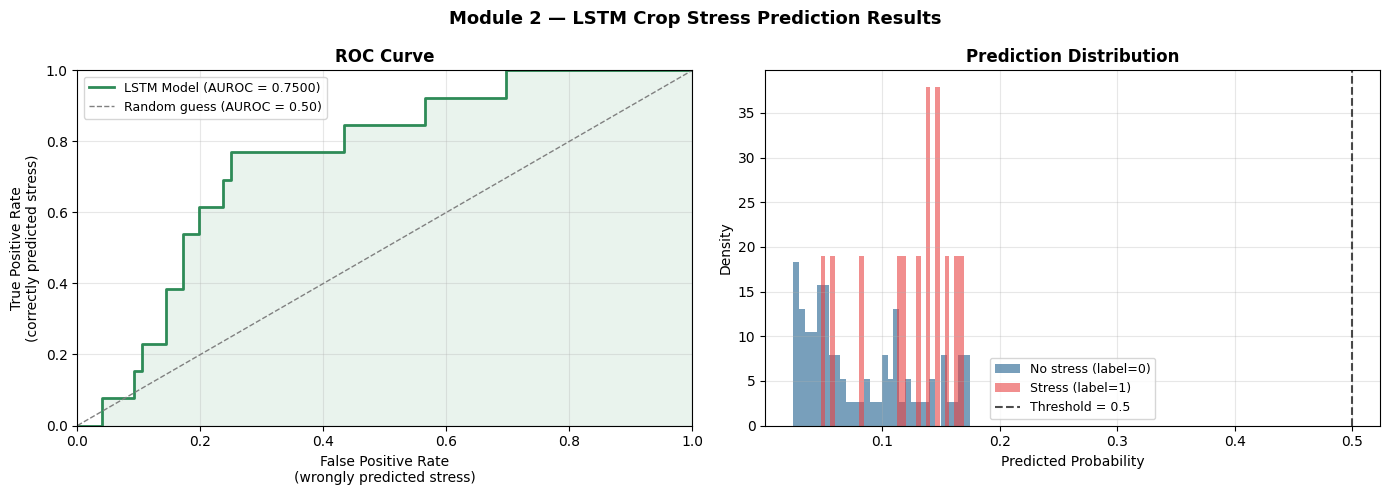

ROC curve saved.

Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

   No Stress       0.85      1.00      0.92        76
      Stress       0.00      0.00      0.00        13

    accuracy                           0.85        89
   macro avg       0.43      0.50      0.46        89
weighted avg       0.73      0.85      0.79        89

Best threshold : 0.116
  True Positive Rate  : 0.769  (caught 76.9% of stress events)
  False Positive Rate : 0.250  (false alarm rate: 25.0%)

Results saved to ./outputs_module2/module2_results.txt


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import torch


# ── Load best model ───────────────────────────────────────────────────────────
print('Loading best model...')
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print('Best model loaded.')

# ── Get predictions on test set ───────────────────────────────────────────────
print('Running predictions on test set...')

all_probs  = []   # predicted probabilities (0 to 1)
all_labels = []   # true labels (0 or 1)

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(DEVICE)
        labels    = labels.to(DEVICE)

        probs = model(sequences)   # probabilities between 0 and 1

        all_probs .extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

print(f'Test sequences evaluated: {len(all_probs)}')

# ── Calculate AUROC ───────────────────────────────────────────────────────────
auroc = roc_auc_score(all_labels, all_probs)
print(f'\nAUROC Score: {auroc:.4f}')

if auroc >= 0.80:
    print('Target met: AUROC > 0.80')
else:
    print(f'Target not met. Gap: {0.80 - auroc:.4f}')

# ── Calculate ROC curve points ────────────────────────────────────────────────
# fpr = false positive rate at each threshold
# tpr = true positive rate at each threshold
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# ── Plot ROC curve ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 2 — LSTM Crop Stress Prediction Results',
             fontsize=13, fontweight='bold')

# Left plot — ROC curve
axes[0].plot(fpr, tpr,
             color='#2e8b57', linewidth=2,
             label=f'LSTM Model (AUROC = {auroc:.4f})')
axes[0].plot([0, 1], [0, 1],
             color='gray', linewidth=1,
             linestyle='--', label='Random guess (AUROC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2e8b57')
axes[0].set_xlabel('False Positive Rate\n(wrongly predicted stress)', fontsize=10)
axes[0].set_ylabel('True Positive Rate\n(correctly predicted stress)', fontsize=10)
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Right plot — prediction probability distribution
axes[1].hist(all_probs[all_labels == 0], bins=30,
             alpha=0.6, color='#1e5f8e',
             label='No stress (label=0)', density=True)
axes[1].hist(all_probs[all_labels == 1], bins=30,
             alpha=0.6, color='#e84343',
             label='Stress (label=1)', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--',
                alpha=0.7, label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)
axes[1].set_title('Prediction Distribution', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('ROC curve saved.')

# ── Classification report at threshold 0.5 ───────────────────────────────────
# Convert probabilities to binary predictions using threshold 0.5
predictions = (all_probs >= 0.5).astype(int)

print(f'\nClassification Report (threshold = 0.5):')
print(classification_report(
    all_labels, predictions,
    target_names=['No Stress', 'Stress'],
    zero_division=0
))

# ── Best threshold ────────────────────────────────────────────────────────────
# Find the threshold that gives the best balance between
# true positive rate and false positive rate
best_idx       = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
best_tpr       = tpr[best_idx]
best_fpr       = fpr[best_idx]

print(f'Best threshold : {best_threshold:.3f}')
print(f'  True Positive Rate  : {best_tpr:.3f}  (caught {best_tpr*100:.1f}% of stress events)')
print(f'  False Positive Rate : {best_fpr:.3f}  (false alarm rate: {best_fpr*100:.1f}%)')

# Save results to text file
with open(f'{OUTPUT_DIR}/module2_results.txt', 'w') as f:
    f.write(f'Module 2 — LSTM Crop Stress Prediction Results\n')
    f.write(f'{"="*50}\n')
    f.write(f'AUROC Score    : {auroc:.4f}\n')
    f.write(f'Best Threshold : {best_threshold:.3f}\n')
    f.write(f'True Pos Rate  : {best_tpr:.3f}\n')
    f.write(f'False Pos Rate : {best_fpr:.3f}\n\n')
    f.write(classification_report(
        all_labels, predictions,
        target_names=['No Stress', 'Stress'],
        zero_division=0
    ))

print(f'\nResults saved to {OUTPUT_DIR}/module2_results.txt')